In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
#from sklearn.metrics import r2_score

https://stackoverflow.com/questions/79511188/gauss-fitting-data-with-scipy-and-getting-strange-answers-on-fit-quality

In [112]:
def model(x, A):
    law = stats.norm()
    return A * law.pdf(x) / law.pdf(0.)

In [113]:
x = np.linspace(-10, 10, 30)

In [128]:
sigmas = np.logspace(-2, 1, 10)
sigmas

array([ 0.01      ,  0.02154435,  0.04641589,  0.1       ,  0.21544347,
        0.46415888,  1.        ,  2.15443469,  4.64158883, 10.        ])

[9.99560914] [[3.00675099e-05]]
[10.00469291] [[0.00016135]]
[10.02362177] [[0.00070312]]
[9.96712682] [[0.00375944]]
[10.01029897] [[0.01575197]]
[9.93282447] [[0.09678946]]
[10.92204219] [[0.32081021]]
[11.4729461] [[1.63214918]]
[15.70427275] [[7.71528098]]
[11.55419149] [[33.89429968]]


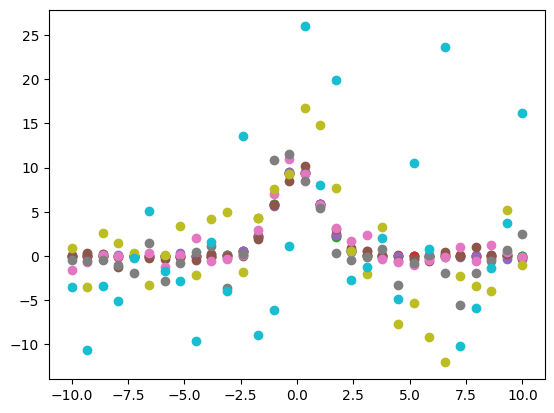

In [132]:
fig, axe = plt.subplots()
results = []
for sigma in sigmas:
    y = model(x, A=10.)
    s = sigma * np.ones_like(y)
    yn = y + s * np.random.randn(y.size)
    popt, pcov = optimize.curve_fit(model, x, yn)
    print(popt, pcov)
    axe.scatter(x, yn)
    cond = np.linalg.cond(pcov)
    results.append({
        "sigma": sigma,
        "cond": cond,
    })
results = pd.DataFrame(results)

In [131]:
results

,sigma,cond
0,0.010000,1.0
1,0.021544,1.0
2,0.046416,1.0
3,0.100000,1.0
4,0.215443,1.0
5,0.464159,1.0
6,1.000000,1.0
7,2.154435,1.0
8,4.641589,1.0
9,10.000000,1.0
